In [13]:
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# ПАРАМЕТРЫ
EPOCHS = 30
LR = 0.0069
BATCH_SIZE = 64
VAL_SIZE = 0.2

### Предобработка данных

In [ ]:
# Чтение файла
def read_file(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return f.read()

# Разбиение текста на отрывки
def chunk_text(text, chunk_size=200, step=200):
    tokens = text.split()
    chunks = []
    start = 0
    while start < len(tokens):
        chunk = tokens[start:start+chunk_size]
        if not chunk:
            break
        chunks.append(" ".join(chunk))
        start += step
    return chunks

# Функция для определения размера чанка в зависимости от текста
def get_stats_based_chunk_params(text, factor=3, step_fraction=0.5):
    # Разбиваем текст на предложения по знакам окончания
    sentences = re.split(r'[.!?]', text)
    lengths = []
    for s in sentences:
        s = s.strip() # Убираем лишние пробелы
        if s:
            # Считаем количество слов в предложении
            lengths.append(len(s.split()))

    # Если в тексте не удалось найти слов, возвращаем значения по умолчанию
    if not lengths:
        return 100, 50
    
    # Вычисляем 75-й процентиль от длин предложений
    perc_75 = np.percentile(lengths, 75)
    chunk_size = int(perc_75 * factor)
    chunk_size = max(50, chunk_size) # Минимальный размер чанка — 50 слов

    # Шаг сдвига окна — часть от размера чанка
    step_size = int(chunk_size * step_fraction)
    step_size = max(25, step_size) # Минимальный шаг — 25 слов

    return chunk_size, step_size

import random

# Функция для подготовки обучающих чанков текста с переменным размером и шагом
def prepare_author_chunks_variable(author_files, min_chunk_size=100, max_chunk_size=500, min_step_factor=0.5, max_step_factor=1.0):
    texts, labels, label2author = [], [], {}
    # Перебираем файлы каждого автора
    for label_idx, filepath in enumerate(author_files):
        author_name = os.path.splitext(os.path.basename(filepath))[0]
        label2author[label_idx] = author_name
        # Читаем текст из файлаы
        text = read_file(filepath)
        tokens = text.split()
        start = 0 # Начальная позиция для формирования чанков
        while start < len(tokens):
            # Случайным образом выбираем размер чанка в заданных пределах
            chunk_size = random.randint(min_chunk_size, max_chunk_size)
            # Случайным образом выбираем фактор шага в пределах от min до max
            step_factor = random.uniform(min_step_factor, max_step_factor)
            # Вычисляем шаг сдвига окна — сколько токенов пропустить до следующего чанка
            step_size = max(1, int(chunk_size * step_factor))  # защита от нуля
            # Получаем чанк токенов текущего размера
            chunk = tokens[start:start + chunk_size]
            if not chunk:
                break
            # Добавляем чанк текста и метку автора
            texts.append(" ".join(chunk))
            labels.append(label_idx)
            # Сдвигаем окно на рассчитанный шаг
            start += step_size
    return texts, labels, label2author



### Классы датасета и персептрона

In [15]:
class TextDataset(Dataset):
    def __init__(self, X_vectors, y_labels):
        if hasattr(X_vectors, 'toarray'):
            X_vectors = X_vectors.toarray()
        self.X = torch.tensor(X_vectors, dtype=torch.float32)
        self.y = torch.tensor(y_labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, output_dim=6, dropout_rate=0.46):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### Функции для обучения и предсказания

In [16]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_acc, best_state_dict = 0.0, None

    for epoch in range(1, epochs+1):
        model.train()
        total_train_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)

        model.eval()
        val_loss, all_preds, all_targets = 0, [], []
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                val_loss += criterion(outputs, y).item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())
        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(all_targets, all_preds)
        print(f"Epoch [{epoch}/{epochs}]: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = model.state_dict()

    if best_state_dict:
        model.load_state_dict(best_state_dict)
    return model

def predict_text(model, vectorizer, text, chunk_size=200, step=200, device='cpu'):
    model.eval()
    chunks = chunk_text(text, chunk_size, step)
    if not chunks:
        return 0
    X = vectorizer.transform(chunks)
    X_torch = torch.tensor(X.toarray(), dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_torch)
        return torch.argmax(logits.sum(dim=0)).item()

def predict_text_dynamic(model, vectorizer, text, device='cpu'):
    cs, ss = get_stats_based_chunk_params(text)
    chunks = chunk_text(text, cs, ss)
    
    if not chunks:
        return 0
    
    X = vectorizer.transform(chunks)
    X_torch = torch.tensor(X.toarray(), dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_torch)
        return torch.argmax(logits.sum(dim=0)).item()

### Подготовка данных: загрузка текстов, нарезка чанков, визуализация распределения чанков

Using device: cuda
Всего чанков (фрагментов) после нарезки: 8234
Train chunks: 6587, Val chunks: 1647


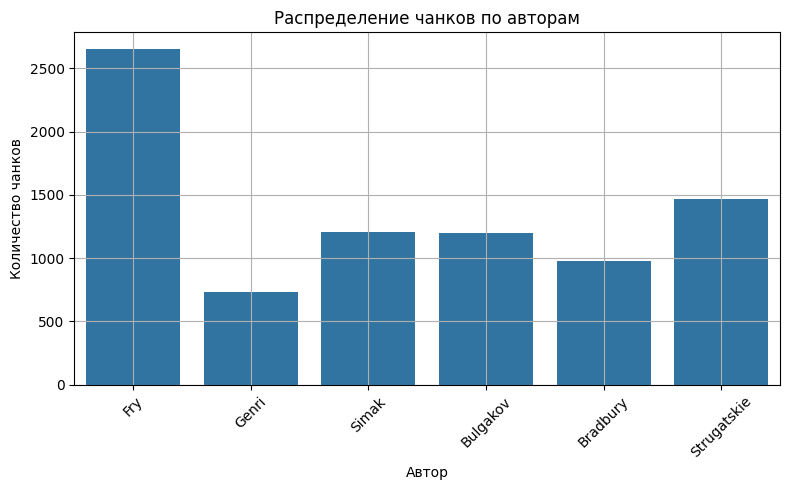

Автор: Fry
﻿Власть несбывшегося – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне ежедневно снится какая-то дичь! – сердито сказал я Джуффину. – Сглазили они меня, что ли? А собственно, почему бы и нет!.. – Я даже не стану тратить драгоценное время на то, чтобы тебя успокаивать: ты и сам отлично понимаешь, что метешь чушь! – улыбнулся шеф, заботливо пододвигая ко мне кружку с горячей камрой. – Просто ты не любишь, когда тебя будят на рассвете, и первые полчаса готов ворчать по любому поводу, как старый хрыч, предчувствующий приближение очередного приступа ревматизма… Никто тебя не сглазил, и так называемая дичь снится тебе отнюдь не ежедневно. Ну разве что сегодня, если не врешь… И поделом, между прочим! Нечего так беззастенчиво дрыхнуть на рабочем месте. – Все претензии к внезапно угомонившимся друзьям вашей бурной юности, – проворчал я. – Я же не виноват, что они больше не хотят совершать всякие ужасные преступления. Чем только не приходится заниматься, чтобы не р

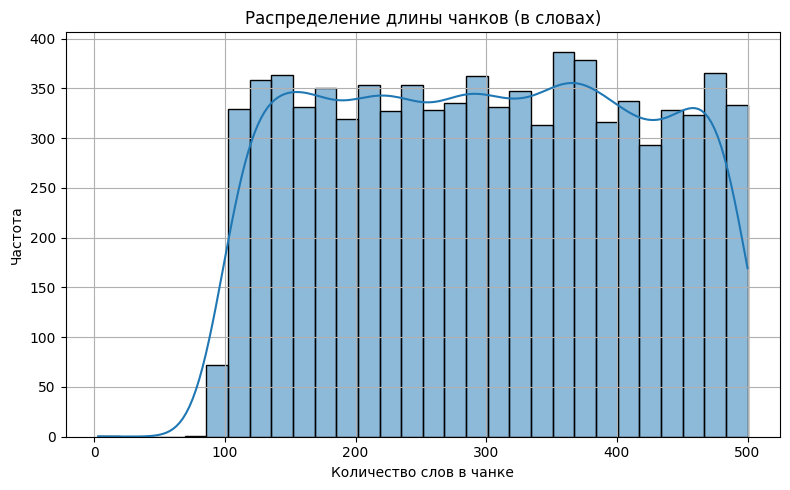


--- Обучение модели ---
Epoch [1/30]: Train Loss = 0.6487, Val Loss = 0.1175, Val Acc = 0.9787
Epoch [2/30]: Train Loss = 0.0491, Val Loss = 0.0557, Val Acc = 0.9872
Epoch [3/30]: Train Loss = 0.0149, Val Loss = 0.0457, Val Acc = 0.9897
Epoch [4/30]: Train Loss = 0.0089, Val Loss = 0.0409, Val Acc = 0.9872
Epoch [5/30]: Train Loss = 0.0056, Val Loss = 0.0360, Val Acc = 0.9897
Epoch [6/30]: Train Loss = 0.0032, Val Loss = 0.0352, Val Acc = 0.9897
Epoch [7/30]: Train Loss = 0.0026, Val Loss = 0.0334, Val Acc = 0.9897
Epoch [8/30]: Train Loss = 0.0020, Val Loss = 0.0323, Val Acc = 0.9891
Epoch [9/30]: Train Loss = 0.0018, Val Loss = 0.0319, Val Acc = 0.9909
Epoch [10/30]: Train Loss = 0.0017, Val Loss = 0.0328, Val Acc = 0.9891
Epoch [11/30]: Train Loss = 0.0011, Val Loss = 0.0305, Val Acc = 0.9897
Epoch [12/30]: Train Loss = 0.0012, Val Loss = 0.0301, Val Acc = 0.9909
Epoch [13/30]: Train Loss = 0.0009, Val Loss = 0.0315, Val Acc = 0.9885
Epoch [14/30]: Train Loss = 0.0008, Val Loss = 0

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

author_files = ["Fry.txt", "Genri.txt", "Simak.txt", "Bulgakov.txt", "Bradbury.txt", "Strugatskie.txt"]
path_to_files = "texts/"
full_paths = [os.path.join(path_to_files, filename) for filename in author_files]

texts, labels, label2author = prepare_author_chunks_variable(full_paths)
num_classes = len(label2author)

print("Всего чанков (фрагментов) после нарезки:", len(texts))

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=VAL_SIZE, random_state=42, stratify=labels)
print(f"Train chunks: {len(train_texts)}, Val chunks: {len(val_texts)}")

# Визуализация
label_counts = Counter(labels)
author_names = [label2author[i] for i in sorted(label2author)]

plt.figure(figsize=(8, 5))
sns.barplot(x=author_names, y=[label_counts[i] for i in range(len(author_names))])
plt.title("Распределение чанков по авторам")
plt.xlabel("Автор")
plt.ylabel("Количество чанков")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

for i in range(len(label2author)):
    sample_idx = labels.index(i)
    print(f"Автор: {label2author[i]}")
    print(texts[sample_idx])
    print("-" * 80)

vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2), analyzer='word', token_pattern=r'\w+')
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

train_dataset = TextDataset(X_train, train_labels)
val_dataset = TextDataset(X_val, val_labels)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

chunk_lengths = [len(chunk.split()) for chunk in texts]
plt.figure(figsize=(8, 5))
sns.histplot(chunk_lengths, bins=30, kde=True)
plt.title("Распределение длины чанков (в словах)")
plt.xlabel("Количество слов в чанке")
plt.ylabel("Частота")
plt.grid(True)
plt.tight_layout()
plt.show()

input_dim = X_train.shape[1]
model = MLP(input_dim, hidden_dim=74, output_dim=num_classes).to(device)

print("\n--- Обучение модели ---")
model = train_model(model, train_loader, val_loader, EPOCHS, LR, device)

In [18]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        preds = torch.argmax(model(X), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.cpu().numpy())

val_acc = accuracy_score(all_true, all_preds)
print("\n=== Итоговая оценка на валидационной выборке ===")
print(f"Val Accuracy: {val_acc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=[label2author[i] for i in range(num_classes)]))

# Тестовые данные
df = pd.read_csv("author_classification.csv")
test_true = []
test_pred = []

test_files_dir = "texts/"

print("\n--- Классификация тестовых файлов ---")
for _, row in df.iterrows():
    fname = os.path.join(test_files_dir, row['filename'])
    true_author = row['author']
    
    if not os.path.exists(fname):
        print(f"Файл {fname} не найден, пропуск...")
        continue
    
    text = read_file(fname)
    pred_label = predict_text(model, vectorizer, text, chunk_size=300, step=150, device=device)
    pred_author = label2author[pred_label]
    
    test_true.append(true_author)
    test_pred.append(pred_author)
    
    print(f"Файл {fname} -> предсказанный автор: {pred_author} (истинный: {true_author})")

print("\n=== Оценка на 21 тестовом отрывке ===")
print("Accuracy:", accuracy_score(test_true, test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(test_true, test_pred, labels=list(label2author.values())))
print("\nClassification Report:")
print(classification_report(test_true, test_pred, labels=list(label2author.values())))

# С динамическими параметрами
df = pd.read_csv("author_classification.csv")
test_true = []
test_pred = []

print("\n--- Классификация тестовых файлов с динамическим подбором параметров (статистика по предложениям) ---")
for _, row in df.iterrows():
    fname = os.path.join(test_files_dir, row['filename'])
    true_author = row['author']
    
    if not os.path.exists(fname):
        print(f"Файл {fname} не найден, пропуск...")
        continue
    
    text = read_file(fname)
    pred_label = predict_text_dynamic(model, vectorizer, text, device=device)
    pred_author = label2author[pred_label]
    
    test_true.append(true_author)
    test_pred.append(pred_author)
    
    print(f"Файл {fname} -> предсказанный автор: {pred_author} (истинный: {true_author})")

print("\n=== Оценка на 21 тестовом отрывке (динамические параметры по статистике) ===")
print("Accuracy:", accuracy_score(test_true, test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(test_true, test_pred, labels=list(label2author.values())))
print("\nClassification Report:")
print(classification_report(test_true, test_pred, labels=list(label2author.values())))

print("\nПримеры ошибок на тестовой выборке:")
for true, pred, fname in zip(test_true, test_pred, df['filename']):
    if true != pred:
        print(f"Файл: {fname} | Истинный автор: {true} | Предсказано: {pred}")


=== Итоговая оценка на валидационной выборке ===
Val Accuracy: 0.9897
Confusion Matrix:
[[527   1   0   0   2   1]
 [  0 144   0   0   1   2]
 [  1   1 238   1   0   0]
 [  0   0   0 239   0   0]
 [  2   0   0   0 193   0]
 [  2   0   1   0   2 289]]

Classification Report:
              precision    recall  f1-score   support

         Fry       0.99      0.99      0.99       531
       Genri       0.99      0.98      0.98       147
       Simak       1.00      0.99      0.99       241
    Bulgakov       1.00      1.00      1.00       239
    Bradbury       0.97      0.99      0.98       195
 Strugatskie       0.99      0.98      0.99       294

    accuracy                           0.99      1647
   macro avg       0.99      0.99      0.99      1647
weighted avg       0.99      0.99      0.99      1647


--- Классификация тестовых файлов ---
Файл texts/author1.txt -> предсказанный автор: Genri (истинный: Genri)
Файл texts/author2.txt -> предсказанный автор: Simak (истинный: Simak)
